# Análise de Gastos e Poupança
### Onde o dinheiro vai e onde é possível economizar

Este notebook analisa os hábitos financeiros de 20.000 indivíduos indianos, explorando como a renda é distribuída entre diferentes categorias de gastos, onde existe margem real para economizar e de que forma a renda influencia a capacidade de poupança.

**Dataset:** [Indian Personal Finance and Spending Habits](https://www.kaggle.com/datasets/shriyashjagtap/indian-personal-finance-and-spending-habits)

## 1. Carregamento dos dados

O dataset é carregado diretamente do Kaggle, sem necessidade de upload manual.

In [9]:
csv_file = '../dataset/data.csv'

In [10]:
import pandas as pd

df = pd.read_csv(csv_file)
df.head()

,Income,Age,Dependents,Occupation,City_Tier,Rent,Loan_Repayment,Insurance,Groceries,Transport,...,Desired_Savings,Disposable_Income,Potential_Savings_Groceries,Potential_Savings_Transport,Potential_Savings_Eating_Out,Potential_Savings_Entertainment,Potential_Savings_Utilities,Potential_Savings_Healthcare,Potential_Savings_Education,Potential_Savings_Miscellaneous
0,44637.249636,49,0,Self_Employed,Tier_1,13391.174891,0.000000,2206.490129,6658.768341,2636.970696,...,6200.537192,11265.627707,1685.696222,328.895281,465.769172,195.151320,678.292859,67.682471,0.000000,85.735517
1,26858.596592,34,2,Retired,Tier_2,5371.719318,0.000000,869.522617,2818.444460,1543.018778,...,1923.176434,9676.818733,540.306561,119.347139,141.866089,234.131168,286.668408,6.603212,56.306874,97.388606
2,50367.605084,35,1,Student,Tier_3,7555.140763,4612.103386,2201.800050,6313.222081,3221.396403,...,7050.360422,13891.450624,1466.073984,473.549752,410.857129,459.965256,488.383423,7.290892,106.653597,138.542422
3,101455.600247,21,0,Self_Employed,Tier_3,15218.340037,6809.441427,4889.418087,14690.149363,7106.130005,...,16694.965136,31617.953615,1875.932770,762.020789,1241.017448,320.190594,1389.815033,193.502754,0.000000,296.041183
4,24875.283548,52,4,Professional,Tier_2,4975.056710,3112.609398,635.907170,3034.329665,1276.155163,...,1874.099434,6265.700532,788.953124,68.160766,61.712505,187.173750,194.117130,47.294591,67.388120,96.557076


## 2. Exploração inicial

Antes de partir para a análise, é importante entender com o que estamos trabalhando: quantos registros existem, quais colunas estão disponíveis e se há dados ausentes que possam comprometer os resultados.

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 27 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Income                           20000 non-null  float64
 1   Age                              20000 non-null  int64  
 2   Dependents                       20000 non-null  int64  
 3   Occupation                       20000 non-null  object 
 4   City_Tier                        20000 non-null  object 
 5   Rent                             20000 non-null  float64
 6   Loan_Repayment                   20000 non-null  float64
 7   Insurance                        20000 non-null  float64
 8   Groceries                        20000 non-null  float64
 9   Transport                        20000 non-null  float64
 10  Eating_Out                       20000 non-null  float64
 11  Entertainment                    20000 non-null  float64
 12  Utilities         

O dataset conta com 20.000 registros e 27 colunas, sem nenhum valor ausente. Isso garante consistência nas análises e elimina a necessidade de tratamento prévio dos dados, permitindo focar diretamente na interpretação dos padrões financeiros.

In [12]:
df.describe()

,Income,Age,Dependents,Rent,Loan_Repayment,Insurance,Groceries,Transport,Eating_Out,Entertainment,...,Desired_Savings,Disposable_Income,Potential_Savings_Groceries,Potential_Savings_Transport,Potential_Savings_Eating_Out,Potential_Savings_Entertainment,Potential_Savings_Utilities,Potential_Savings_Healthcare,Potential_Savings_Education,Potential_Savings_Miscellaneous
count,2.000000e+04,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,...,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000
mean,4.158550e+04,41.031450,1.995950,9115.494629,2049.800292,1455.028761,5205.667493,2704.466685,1461.856982,1448.853658,...,4982.878416,10647.367257,912.197183,473.042650,254.963280,254.031058,436.332808,41.524964,62.417083,144.904987
std,4.001454e+04,13.578725,1.417616,9254.228188,4281.789941,1492.938435,5035.953689,2666.345648,1481.660811,1489.019270,...,7733.468188,11740.637289,1038.884968,537.222853,296.047943,299.973590,503.200658,53.152458,98.842656,169.160951
min,1.301187e+03,18.000000,0.000000,235.365692,0.000000,30.002012,154.078240,81.228584,39.437523,45.421469,...,0.000000,-5400.788673,16.575501,8.268076,3.797926,3.121610,6.200297,0.001238,0.000000,2.091973
25%,1.760488e+04,29.000000,1.000000,3649.422246,0.000000,580.204749,2165.426419,1124.578012,581.011801,581.632906,...,1224.932636,3774.894323,317.811000,161.913751,84.506870,84.562090,148.013618,11.037421,4.926210,47.637307
50%,3.018538e+04,41.000000,2.000000,6402.751824,0.000000,1017.124681,3741.091535,1933.845509,1029.109726,1020.198376,...,2155.356763,7224.890977,607.038735,307.045856,164.927660,164.740232,285.739582,25.202124,33.127987,93.090257
75%,5.176545e+04,53.000000,3.000000,11263.940492,2627.142320,1787.160895,6470.892718,3360.597508,1807.075251,1790.104082,...,6216.309609,13331.950716,1128.681837,588.419602,313.398240,310.927935,538.983703,52.353736,80.946145,178.257981
max,1.079728e+06,64.000000,4.000000,215945.674703,123080.682009,38734.932935,119816.898124,81861.503457,34406.100166,38667.368308,...,245504.485208,377060.218482,34894.644404,12273.258242,5573.036433,6222.200913,8081.799518,1394.531049,3647.244243,4637.951137


As estatísticas descritivas já revelam algo interessante: a renda média gira em torno de 41.500, mas o valor máximo ultrapassa 1.000.000. Essa grande dispersão indica que a base inclui perfis financeiros muito distintos, desde pessoas de baixa renda até indivíduos com renda bastante elevada. A análise por faixas de renda, feita mais adiante, vai explorar justamente esse contraste.

## 3. Gasto médio por categoria

O primeiro passo é entender para onde vai o dinheiro. Analisar o gasto médio por categoria permite identificar quais despesas dominam o orçamento da população estudada.

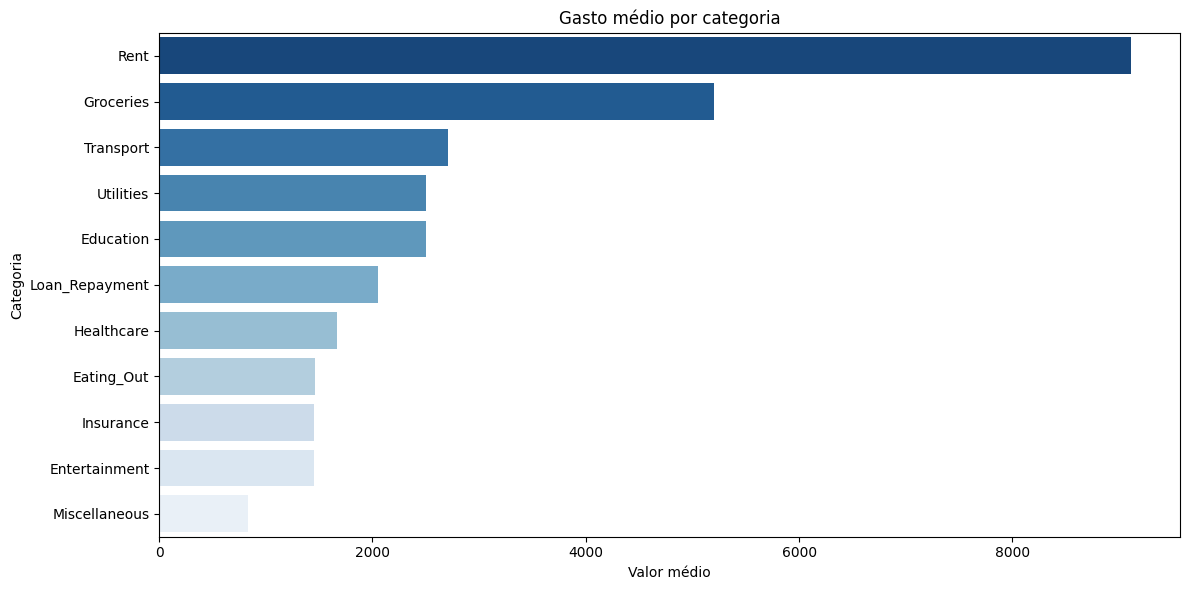

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

colunas_gastos = ['Rent', 'Loan_Repayment', 'Insurance', 'Groceries',
                  'Transport', 'Eating_Out', 'Entertainment',
                  'Utilities', 'Healthcare', 'Education', 'Miscellaneous']

medias = df[colunas_gastos].mean().sort_values(ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(x=medias.values, y=medias.index, hue=medias.index, palette='Blues_r', legend=False)
plt.title('Gasto médio por categoria')
plt.xlabel('Valor médio')
plt.ylabel('Categoria')
plt.tight_layout()
plt.show()

O aluguel se destaca como o maior gasto médio, indicando que uma parcela significativa da renda está comprometida com despesas fixas. Em seguida, alimentação (Groceries) aparece como segunda maior categoria, superando inclusive custos como empréstimos e seguros, o que reforça seu peso no orçamento mensal.

Categorias como entretenimento e saúde, embora apresentem valores menores individualmente, quando consideradas em conjunto representam uma parcela relevante dos gastos. Isso sugere que, apesar de menos impactantes isoladamente, esses custos podem oferecer maior flexibilidade para ajustes, especialmente em estratégias de redução de despesas.

## 4. Economia potencial por categoria

Saber onde se gasta mais é só metade da história. A outra metade é entender onde existe margem real para reduzir gastos sem comprometer o essencial.

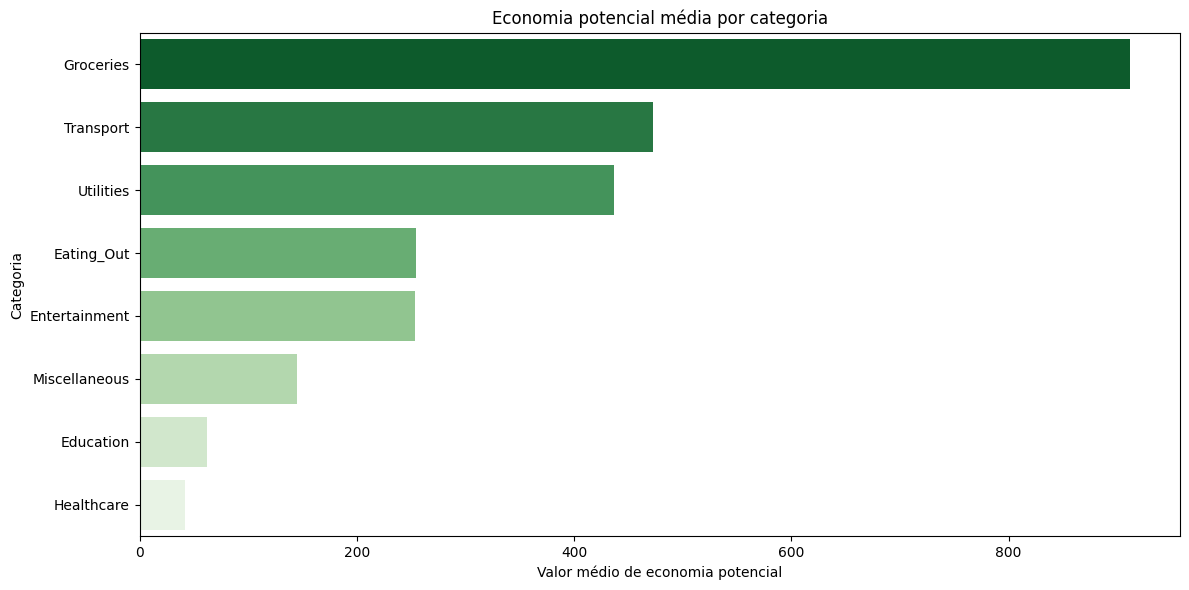

In [14]:
colunas_savings = ['Potential_Savings_Groceries', 'Potential_Savings_Transport',
                   'Potential_Savings_Eating_Out', 'Potential_Savings_Entertainment',
                   'Potential_Savings_Utilities', 'Potential_Savings_Healthcare',
                   'Potential_Savings_Education', 'Potential_Savings_Miscellaneous']

medias_savings = df[colunas_savings].mean().sort_values(ascending=False)

medias_savings.index = [i.replace('Potential_Savings_', '') for i in medias_savings.index]

plt.figure(figsize=(12, 6))
sns.barplot(x=medias_savings.values, y=medias_savings.index, hue=medias_savings.index, palette='Greens_r', legend=False)
plt.title('Economia potencial média por categoria')
plt.xlabel('Valor médio de economia potencial')
plt.ylabel('Categoria')
plt.tight_layout()
plt.show()

Alimentação lidera o potencial de economia, seguida de transporte e contas de utilidades, indicando que essas categorias concentram maior margem de ajuste no orçamento. Em contraste, saúde aparece no fim da lista, com o menor potencial de corte, o que não significa baixo gasto, mas sim baixa flexibilidade para redução sem impactos relevantes.

Esse padrão reforça que os maiores ganhos financeiros tendem a estar nas despesas recorrentes do dia a dia, que oferecem maior possibilidade de ajuste, enquanto gastos mais essenciais apresentam maior rigidez e menor capacidade de redução.

## 5. Gasto médio vs economia potencial por categoria

Com os dois gráficos anteriores em mente, vale colocar as informações lado a lado para entender não só onde se gasta mais, mas onde a relação entre gasto e economia potencial é mais favorável.

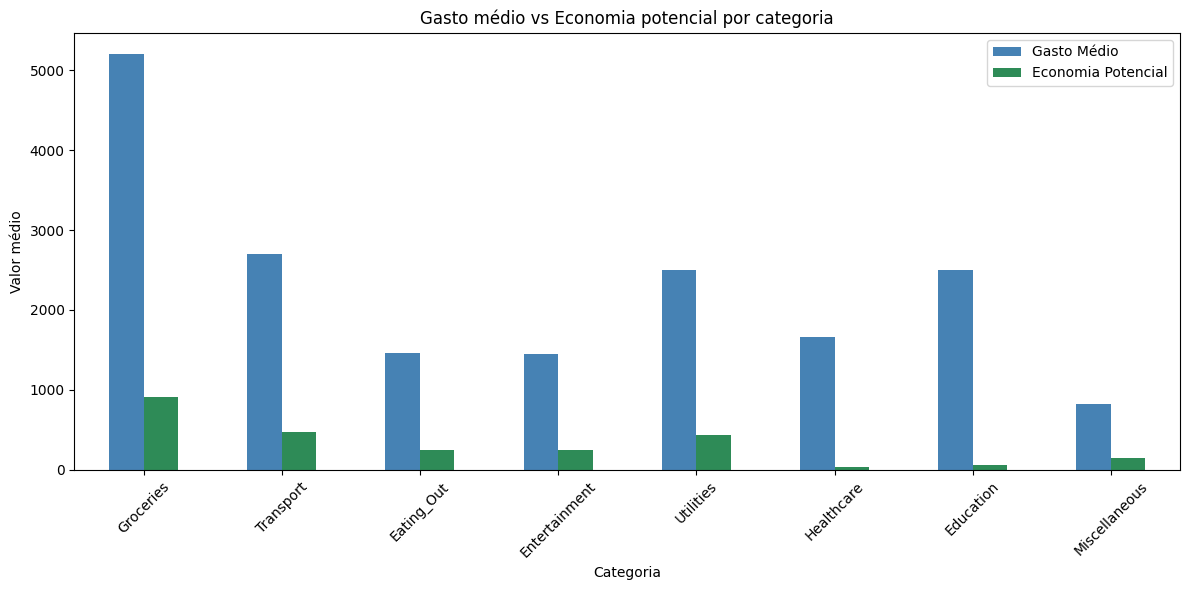

In [15]:
colunas_savings = ['Potential_Savings_Groceries', 'Potential_Savings_Transport',
                   'Potential_Savings_Eating_Out', 'Potential_Savings_Entertainment',
                   'Potential_Savings_Utilities', 'Potential_Savings_Healthcare',
                   'Potential_Savings_Education', 'Potential_Savings_Miscellaneous']

categorias_comuns = ['Groceries', 'Transport', 'Eating_Out', 'Entertainment',
                     'Utilities', 'Healthcare', 'Education', 'Miscellaneous']

gastos_comuns = df[categorias_comuns].mean()
savings_comuns = df[colunas_savings].mean()
savings_comuns.index = categorias_comuns

comparacao = pd.DataFrame({
    'Gasto Médio': gastos_comuns,
    'Economia Potencial': savings_comuns
})

comparacao.plot(kind='bar', figsize=(12, 6), color=['steelblue', 'seagreen'])
plt.title('Gasto médio vs Economia potencial por categoria')
plt.xlabel('Categoria')
plt.ylabel('Valor médio')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Groceries se destaca como a categoria mais estratégica, pois concentra tanto alto nível de gasto quanto elevado potencial de economia. Isso indica que mudanças nos hábitos de consumo com alimentação tendem a gerar impacto direto e relevante no orçamento.

Educação, por outro lado, apresenta o menor potencial de corte proporcional, sugerindo baixa flexibilidade para redução. Esse comportamento indica que esse tipo de gasto é tratado como prioritário, sendo menos suscetível a ajustes mesmo em cenários de restrição financeira.

## 6. Taxa de poupança por faixa de renda

A última análise investiga se ganhar mais se traduz diretamente em poupar mais. Para isso, a renda foi dividida em cinco faixas e calculada a taxa média de poupança de cada grupo.

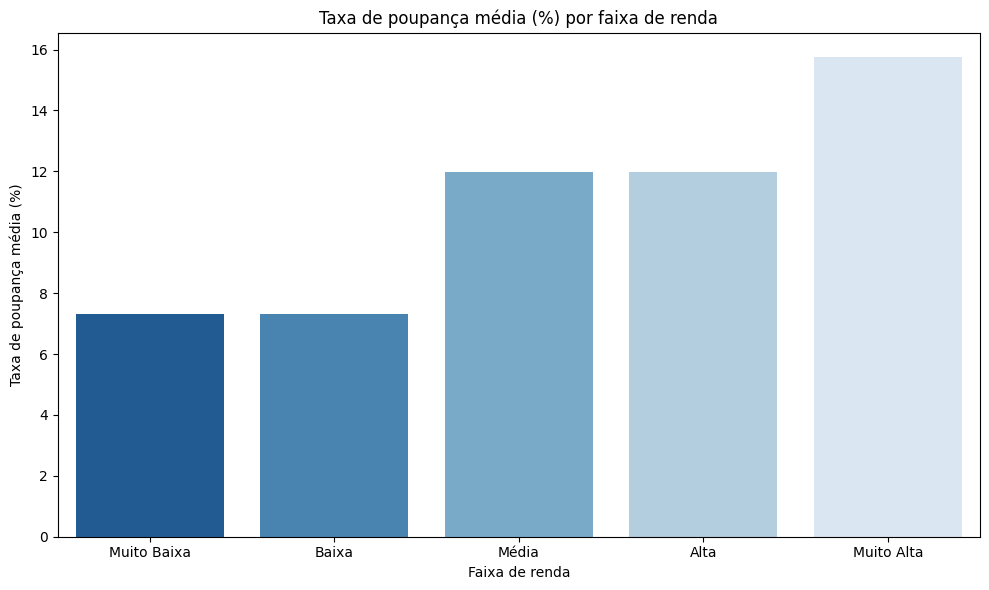

In [16]:
df['Savings_Rate'] = df['Desired_Savings'] / df['Income'] * 100

bins = [0, 20000, 40000, 60000, 80000, df['Income'].max()]
labels = ['Muito Baixa', 'Baixa', 'Média', 'Alta', 'Muito Alta']
df['Income_Group'] = pd.cut(df['Income'], bins=bins, labels=labels)

medias_poupanca = df.groupby('Income_Group', observed=True)['Savings_Rate'].mean()

plt.figure(figsize=(10, 6))
sns.barplot(x=medias_poupanca.index, y=medias_poupanca.values, hue=medias_poupanca.index, palette='Blues_r', legend=False)
plt.title('Taxa de poupança média (%) por faixa de renda')
plt.xlabel('Faixa de renda')
plt.ylabel('Taxa de poupança média (%)')
plt.tight_layout()
plt.show()

As faixas de renda baixa, média e alta apresentam taxas de poupança muito semelhantes entre si, enquanto apenas a faixa de renda muito alta se destaca com uma proporção significativamente maior. Esse padrão indica que, para a maior parte da população, o aumento da renda não se traduz automaticamente em maior capacidade de poupar.

Isso ocorre porque os gastos tendem a crescer junto com a renda, absorvendo boa parte dos ganhos adicionais. Assim, mudanças mais relevantes na capacidade de poupança parecem ocorrer apenas em níveis de renda mais elevados, onde essa relação se torna menos proporcional.

## 7. Conclusões

A análise dos hábitos financeiros de 20.000 indivíduos revelou padrões consistentes sobre como a renda é distribuída e onde existem oportunidades reais de melhoria financeira.

O aluguel domina o orçamento em termos absolutos, mas é uma despesa fixa com pouca margem de negociação. Já a alimentação se mostrou a categoria mais relevante do ponto de vista estratégico: é o segundo maior gasto e também onde existe o maior potencial de economia, o que a torna o principal alvo para quem deseja melhorar sua saúde financeira no curto prazo.

Outro achado importante é que ganhar mais não significa necessariamente poupar mais. As faixas intermediárias de renda apresentam comportamentos muito semelhantes entre si, indicando que o aumento de renda tende a ser consumido por novos gastos. Uma mudança expressiva na taxa de poupança só aparece nos níveis de renda mais elevados, o que reforça a importância de controlar os gastos independentemente do quanto se ganha.